# 03 — Market Regime Discovery (UMAP + HDBSCAN)

**Muc tieu:** Phat hien cac trang thai thi truong (market regime) co cau truc khac biet
trong khong gian vat ly-kinh te vi mo: `[TTF_Gas_Price, Residual_Load, EU_Gas_Storage_Anomaly]`.

**Yeu cau:** Chay `prepare.py` truoc de tao `data/processed/electricity_dataset_with_regimes.csv`
va `artifacts/{country}/scaler.pkl`, `knn_regime.pkl`, `umap_reducer.pkl`.

---

## Ly thuyet nen tang

### 1. Isolation Forest — Phat hien ngoai le (Bước 1)

Isolation Forest (Liu et al., 2008) xay dung mot tap hop cac cay phan tach ngau nhien.
Moi diem du lieu duoc do bang **do dai duong dan phan tach** (isolation path length):
- **Diem ngoai le** (anomaly): bi co lap som voi duong dan ngan → bat thuong.
- **Diem binh thuong**: nam sau trong cay, can nhieu lan phan tach hon.

Thuat toan su dung `contamination=0.05`: 5% quan sat co duong dan phan tach ngan nhat
duoc danh nhan la ngoai le (`Physical_Cluster = -2`).

### 2. Lay mau phan tang theo TTF Gas Quartile (Bước 2)

HDBSCAN la thuat toan phu thuoc mat do nen rat kho ap dung tren tap du lieu lon (420,768 hang):
- **Do phuc tap:** O(n log n) — khong the chay tren toan bo du lieu trong thoi gian hop ly.
- **Giai phap:** Chon ngau nhien 10% mau de HDBSCAN phan cum.

**Tai sao stratify theo TTF Gas Quartile thay vi gia dien?**
HDBSCAN hoat dong tren khong gian 3D `[TTF, Storage, Residual_Load]` — khong phai tren gia dien.
Stratify theo TTF dam bao tap 10% bao phu deu trong khong gian clustering: cac muc TTF thap
(Base regime), trung binh (Transition), cao (Spike), va rat cao (Crisis) deu co dai dien.
Neu stratify theo gia dien, hai diem co cung gia nhung khac TTF/Storage van co the thuoc cum khac nhau,
lam mat tinh dai dien trong khong gian vat ly.

### 3. UMAP — Giam chieu phi tuyen (Bước 3)

UMAP (Uniform Manifold Approximation and Projection; McInnes et al., 2018) xay dung mot
do thi fan (fuzzy topological graph) trong khong gian goc, sau do toi uu hoa vi tri 2D
de bao toan cau truc lan can cuc bo. Khac voi PCA (tuyen tinh), UMAP bat duoc
cau truc phi tuyen:

```
3D: [TTF, Storage, Residual_Load]  --UMAP-->  2D: [UMAP1, UMAP2]
```

**Ly do can giam chieu truoc HDBSCAN:**
Trong khong gian nhieu chieu, hien tuong *concentration of measure* khien mat do diem
phan bo deu khap — HDBSCAN khong phan biet duoc vung day va vung thua. UMAP nen khong gian
de mat do tro nen co nghia hon.

**Tham so da chon:** `n_neighbors=30` (cau truc lan can rong), `min_dist=0.0` (cho phep
cum chat), `n_jobs=1` (dam bao tai tao).

**Luu y thiet ke:** UMAP chi chay tren tap 10% (training set). Voi 90% con lai,
UMAP.transform() duoc goi de lay toa do UMAP1/UMAP2 phuc vu VISUALIZATION — khong phai
de phan loai the che.

### 4. HDBSCAN — Phan cum mat do phan cap (Bước 4)

HDBSCAN (Campello et al., 2013) la phien ban phan cap cua DBSCAN:
1. Tinh **mutual reachability distance**: $d_{mreach}(a,b) = \max(d_{core}(a), d_{core}(b), d(a,b))$
2. Xay dung **minimum spanning tree** tren do thi mutual reachability.
3. Trich xuat cay phan cap dua tren epsilon (nguu mat do).
4. Chon cum on dinh nhat theo chuan **Excess of Mass** — khong can khai bao K truoc.

Nhan `-1` = Noise (diem khong thuoc cum nao). Khac voi ngoai le Isolation Forest,
Noise la diem khong du mat do — co the la diem chuyen tiep giua cac the che.

Sieu tham so duoc tim qua Grid Search: `min_cluster_size` x `min_samples`.
Tieu chi lua chon: **Silhouette Score** cao nhat voi dieu kien Noise < 20%.

### 5. KNN Lan truyen nhan tren khong gian 3D Scaled (Bước 5)

HDBSCAN chi chay tren 10% mau. De gan nhan cho 90% con lai, KNN (k=5) duoc
huan luyen tren **khong gian 3D StandardScaler** (khong phai UMAP 2D).

**Ly do khong dung UMAP 2D de KNN:**
- `UMAP.transform()` tren diem out-of-sample khong dam bao nhat quan voi khong gian training.
- Inference production chi can `scaler.pkl + knn_regime.pkl` (vai KB), khong phai
  UMAP reducer (~5.7 MB/nuoc) + chi phi tinh toan.
- KNN la supervised classifier: no hoc ranh gioi quyet dinh tu labels HDBSCAN (ground truth).
  Viec huan luyen KNN tren khong gian khac HDBSCAN (3D thay vi 2D) hoan toan hop le.

**Tom tat artifacts:**
- `scaler.pkl` + `knn_regime.pkl` → Inference production (predict.py, API/web).
- `umap_reducer.pkl` → Chi visualization trong notebook, khong can thiet luc inference.


In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False
import matplotlib.lines as mlines
import seaborn as sns
warnings.filterwarnings('ignore')
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')
OUT_DIR = 'reports/figures/02_regimes'
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('data/processed/electricity_dataset_with_regimes.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
COUNTRIES = ['DE', 'DK', 'ES', 'FR', 'IT', 'PL']
print(f'{len(df):,} rows | Physical_Cluster distribution:')
print(df['Physical_Cluster'].value_counts().sort_index())

420,768 rows | Physical_Cluster distribution:
Physical_Cluster
-2    21038
-1    13561
 0    52067
 1    48347
 2    64253
 3    68171
 4    73534
 5    29567
 6    23540
 7    15203
 8     4759
 9     6728
Name: count, dtype: int64


## 1. UMAP Projection — 6 Countries (2×3 grid)

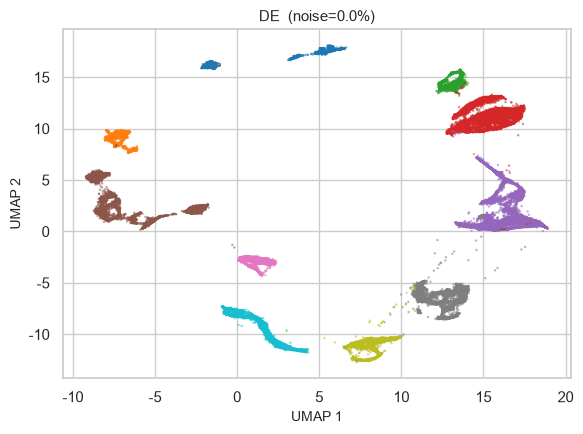

In [3]:
import matplotlib.pyplot as plt

_tab10 = plt.colormaps['tab10']
def get_color(c):
    _base = {-2: '#e74c3c', -1: '#95a5a6'}
    if c in _base:
        return _base[c]
    return _tab10(int(c) % 10)

# DE — toàn bộ điểm, không legend (regime không có tên thực thể)
country = 'DE'
sub = df[(df['Country'] == country) & df['UMAP1'].notna()]
clusters = sorted(sub['Physical_Cluster'].unique())

fig, ax = plt.subplots(figsize=(6, 4.5))
for c in clusters:
    grp = sub[sub['Physical_Cluster'] == c]
    ax.scatter(grp['UMAP1'], grp['UMAP2'],
               color=get_color(c), s=3, alpha=0.55,
               edgecolors='none')

noise_pct = (sub['Physical_Cluster'] == -1).mean() * 100
ax.set_title(f'DE  (noise={noise_pct:.1f}%)', fontsize=11)
ax.set_xlabel('UMAP 1', fontsize=10)
ax.set_ylabel('UMAP 2', fontsize=10)
# Không có legend — màu sắc thể hiện sự tách biệt cụm

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'umap_clusters.png'), dpi=300, bbox_inches='tight')
plt.show()

## 2. Regime Economic Profile (per country)

In [4]:
country = 'DE'  # Change to explore other countries
df_c = df[(df['Country'] == country) & (df['Physical_Cluster'] >= -1)].copy()

stats = df_c.groupby('Physical_Cluster').agg(
    Count=('Real_Wholesale_Price_EUR', 'count'),
    Mean_Price=('Real_Wholesale_Price_EUR', 'mean'),
    Mean_TTF=('TTF_Gas_Price', 'mean'),
    Mean_Load=('Residual_Load', 'mean'),
).round(2)

# Add anomaly row separately
anomaly = df_c[df_c['Physical_Cluster'] == -2].agg(
    {'Real_Wholesale_Price_EUR':'mean','TTF_Gas_Price':'mean','Residual_Load':'mean'}).round(2)

print(f'=== {country} Regime Statistics ===')
stats

=== DE Regime Statistics ===


,Count,Mean_Price,Mean_TTF,Mean_Load
Physical_Cluster,,,,
0,4339,173.74,122.05,32297.61
1,3914,136.72,83.94,36168.63
2,2903,93.29,50.23,30880.87
3,11755,62.68,34.02,26920.49
4,11656,69.56,37.51,29048.71
5,10050,48.06,20.43,36186.60
6,2982,19.65,6.22,29592.95
7,7535,40.85,21.96,39427.84
8,4759,41.03,18.67,36713.82


## 3. Regime Timeline — Physical_Cluster over Time

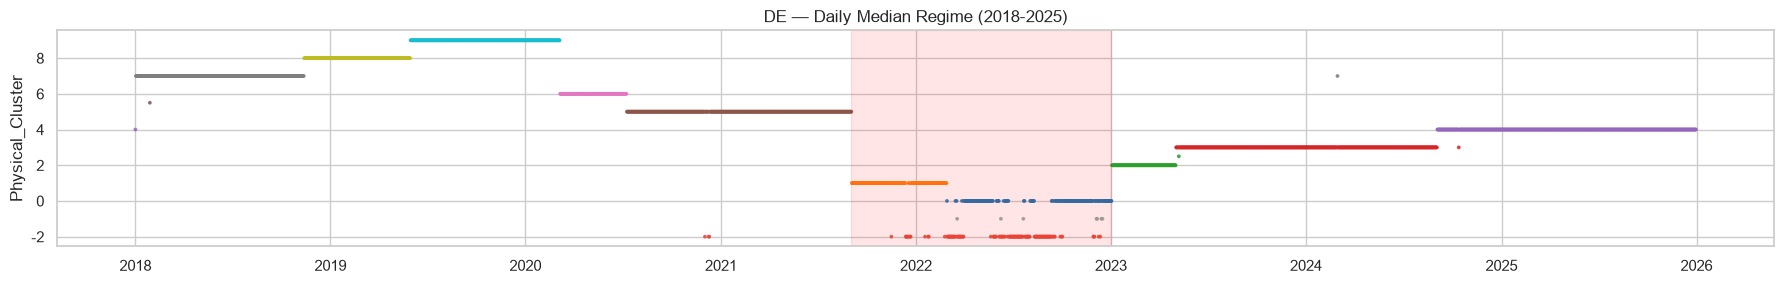

In [5]:
country = 'DE'
df_c = df[df['Country'] == country].copy()
df_c = df_c.sort_values('Datetime')
daily = df_c.set_index('Datetime')['Physical_Cluster'].resample('D').median()

fig, ax = plt.subplots(figsize=(18, 3))
sc = ax.scatter(daily.index, daily.values,
                c=daily.map(lambda x: get_color(int(x) if not pd.isna(x) else -1)),
                s=3, alpha=0.8)
ax.set_title(f'{country} — Daily Median Regime (2018-2025)', fontsize=12)
ax.set_ylabel('Physical_Cluster')
ax.axvspan(pd.Timestamp('2021-09-01',tz='UTC'), pd.Timestamp('2023-01-01',tz='UTC'),
           color='red', alpha=0.1, label='Crisis')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{country}_regime_timeline.png'), dpi=500, bbox_inches='tight')
plt.show()

## 4. OLS Residuals by Regime — Cross-Validation

In [6]:
# Verify: anomaly regimes should have HIGH OLS residuals
from src.models.baseline import fit_ols, SAFE_FEATURES
df_base = pd.read_csv('data/processed/electricity_dataset.csv')

rows = []
for country in COUNTRIES:
    df_c_raw = df_base[df_base['Country'] == country].copy()
    avail = [f for f in SAFE_FEATURES if f in df_c_raw.columns and f != 'Residual_Load']
    _, residuals, _ = fit_ols(df_c_raw, avail)
    df_c = df[df['Country'] == country].copy()
    df_c['OLS_Residual_Abs'] = residuals.abs().reindex(df_c.index).values
    for regime in sorted(df_c['Physical_Cluster'].unique()):
        mean_res = df_c[df_c['Physical_Cluster'] == regime]['OLS_Residual_Abs'].mean()
        rows.append({'Country':country,'Regime':regime,'Mean_Abs_OLS_Residual':round(mean_res,2)})

pd.DataFrame(rows).pivot(index='Regime', columns='Country', values='Mean_Abs_OLS_Residual')

Country,DE,DK,ES,FR,IT,PL
Regime,,,,,,
-2,64.66,74.56,59.75,61.89,48.23,51.06
-1,NaN,NaN,29.42,16.18,8.26,8.55
0,42.67,14.02,24.58,46.98,8.66,8.39
1,26.98,14.83,14.09,17.11,10.32,20.25
2,14.58,21.76,9.86,19.69,12.07,10.39
3,13.42,25.03,17.30,17.86,12.44,14.35
4,14.39,13.76,19.33,12.97,19.81,16.58
5,12.32,15.96,NaN,14.37,NaN,8.13
6,13.52,48.48,NaN,15.22,NaN,9.26


In [7]:
import shutil
import os
OUT_APP = "paper/figures/appendix"
os.makedirs(OUT_APP, exist_ok=True)
OUT_RES = "paper/figures/results"
os.makedirs(OUT_RES, exist_ok=True)

# 1. Copy UMAP to results
src_umap = os.path.join(OUT_DIR, "umap_clusters.png")
if os.path.exists(src_umap):
    shutil.copy(src_umap, os.path.join(OUT_RES, "umap_hdbscan_regime_clusters.png"))

# 2. Plot Regime Timeline for all countries
fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharex=True)
axes = axes.flatten()
for i, c in enumerate(COUNTRIES):
    df_c = df[df['Country'] == c].sort_values('Datetime')
    daily = df_c.set_index('Datetime')['Physical_Cluster'].resample('D').median()
    ax = axes[i]
    ax.scatter(daily.index, daily.values,
               c=daily.map(lambda x: get_color(int(x) if not pd.isna(x) else -1)),
               s=3, alpha=0.8)
    ax.set_title(f'{c} - Daily Median Regime (2018-2025)', fontsize=12)
    ax.axvspan(pd.Timestamp('2021-09-01',tz='UTC'), pd.Timestamp('2023-01-01',tz='UTC'),
               color='red', alpha=0.1, label='Crisis')
    if i % 2 == 0: ax.set_ylabel('Physical_Cluster')
plt.tight_layout()
plt.savefig(os.path.join(OUT_APP, "all_countries_regime_timeline.png"), dpi=500, bbox_inches='tight')
plt.close()

# 3. Plot Regime Price Distribution
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='Physical_Cluster', y='Real_Wholesale_Price_EUR', hue='Physical_Cluster', legend=False, palette='viridis', ax=ax, showfliers=False)
ax.set_title("Distribution of Real Wholesale Price by Physical Regime (All Countries, 2018-2025)", fontsize=13)
ax.set_xlabel("Physical Cluster Regime", fontsize=11)
ax.set_ylabel("Real Wholesale Price (EUR/MWh)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_RES, "regime_price_distribution.png"), dpi=500, bbox_inches='tight')
plt.close()
print("Plots integrated into Notebook 03!")

Plots integrated into Notebook 03!
